# Plot reconstruction error from a teacher sweep

Assumes `examples/tune_architecture_example.py` has already been run and results are in `output/teacher_sweep`.

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import medal

/home/bnc2119/.conda/envs/medal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-18 15:09:32,758	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-18 15:09:33,463	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## 1. Recreate the held-out test set

Use the same data and split as the original script so `X_test` matches what was used during training.

In [2]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data[:5000].astype(np.float32) / 255.0
y = mnist.target[:5000]

_, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}  y_test: {y_test.shape}")

X_test:  (1000, 784)
y_train: (4000,)  y_test: (1000,)


## 2. Load sweep results and compute metrics

In [3]:
results = medal.SweepResults.load("../output/teacher_sweep")
print(f"Teacher:    {results.teacher}")
print(f"Param:      {results.param_name}")
print(f"Values:     {results.param_values}")
print(f"Seeds:      {results.seeds}")

Teacher:    umap
Param:      n_neighbors
Values:     [5, 6, 9, 13, 18, 25, 35, 49, 69, 96, 134, 186, 258, 359, 499]
Seeds:      [0, 1]


In [4]:
df = results.load_metrics(X_test)
df.head()

,n_neighbors,seed,split,recon_loss,distill_mse
0,5,0,Train,0.035779,0.000003
1,5,0,Val,0.048492,NaN
2,5,0,Test,0.050542,NaN
3,5,1,Train,0.035846,0.000003
4,5,1,Val,0.049043,NaN


## 3. Select optimal n_neighbors (one-SEM rule on val loss)

In [5]:
opt = medal.select_teacher_param(df, param_col="n_neighbors")
print(f"Optimal n_neighbors: {opt}")

Optimal n_neighbors: 186


## 4a. Tuning curve

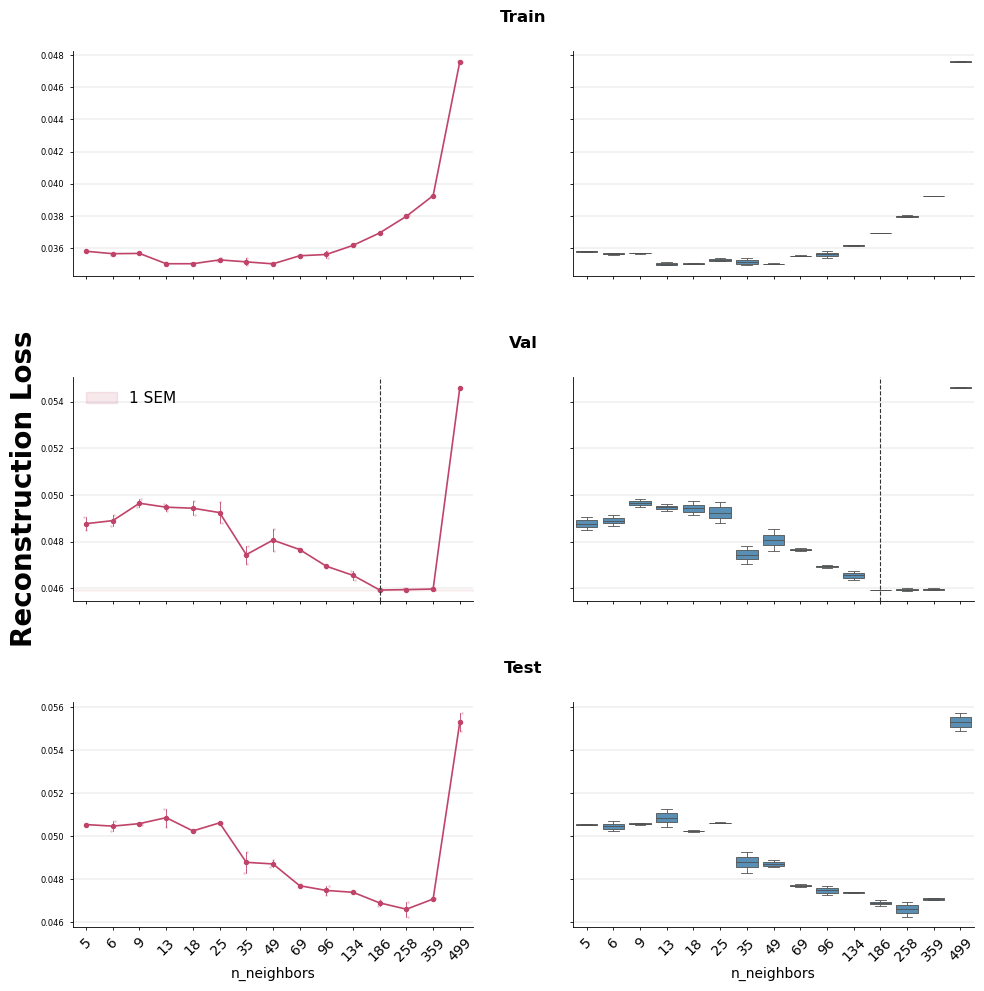

In [6]:
%matplotlib inline
fig = medal.plot_reconstruction_error(df, opt, param_col="n_neighbors", figsize = (10, 10), show_boxplot=True)

## 4b. Distortion map

Load embeddings for the optimal `n_neighbors` only (one checkpoint per seed, single forward pass per split).  
`y_train` are the labels for the full `X_train` passed to `run_teacher_sweep`; `load_embeddings` re-applies the same internal val split to align them.

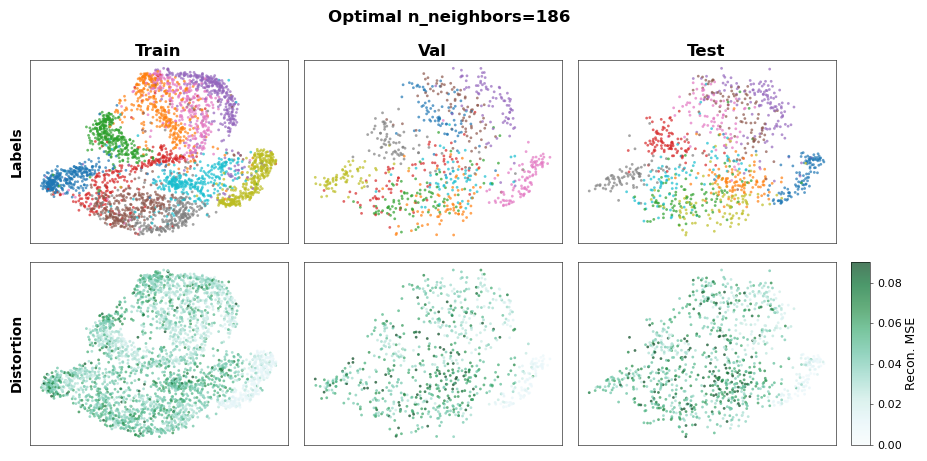

In [8]:
emb_data = results.load_embeddings(
    y_train,
    X_test,
    y_test,
    params=[opt],   # load only the optimal hyperparameter to keep it fast
)

fig = medal.plot_distortion_map(
    emb_data,
    opt,
    param_col="n_neighbors",
    param="best",
    cmap="BuGn"
)